# Exploratory Data Analysis: Mufulira CDF Community Projects

## 1. Introduction

This notebook performs Exploratory Data Analysis (EDA), data quality assessment, and preprocessing of the Mufulira Municipal Council CDF Community Projects dataset.

The dataset was extracted from official Mufulira Municipal Council CDF Community Projects PDF documents for the Kantanshi, Kankoyo, and Mufulira Central constituencies.

The purpose of this analysis is to:

- understand the structure and content of the extracted dataset;
- assess the quality and completeness of the extracted records;
- identify missing, duplicated, inconsistent, or suspicious values;
- identify potential OCR-related extraction issues;
- apply appropriate data cleaning and preprocessing; and
- document the decisions made during the preprocessing process.

The dataset is pipe-delimited (`|`) as required by the project.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "db-unza26-csc4792-mufulira_cdf_projects.csv"

df = pd.read_csv(file_path, sep="|")

df.head()

,Constituency,Project_No,Ward,Project_Name,Sector,Scope_of_Work,Quantity,Location,Proposed_Date,Duration,Engineers_Estimate_ZMW,Approved_Amount_ZMW,Justification,Source_File
0,Kantanshi,1,DAVID KAUNDA,| 2? | PURCHASE OF 985 DESKS MUFULIRA SECONDAR...,EDUCATION,| 2? | Purchase of 985 Desks Mufulira Secondar...,NaN,NaN,NaN,8 WEEKS,374000.0,374000.0,NaN,Kantanshi-Comm-Projects.pdf
1,Kantanshi,3,MAINASOKO,"TWALUBUKA 50 TWALUBUKA 15TH MARCH, 2025 |",NaN,"Twalubuka 50 Twalubuka 15th March, 2025 |Maina...",NaN,NaN,NaN,8 WEEKS,110000.0,110000.0,NaN,Kantanshi-Comm-Projects.pdf
2,Kantanshi,3,MOKAMBO,MURUNDU SECONDARY 40 MURUNDU SECONDARY 15TH MA...,NaN,Murundu Secondary 40 Murundu Secondary 15th Ma...,NaN,NaN,NaN,8 WEEKS,88000.0,88000.0,NaN,Kantanshi-Comm-Projects.pdf
3,Kantanshi,8,MOKAMBO,NaN,NaN,Mokambo Secondary | 40 Mokambo Secondary 15th ...,NaN,NaN,NaN,8 WEEKS,88000.0,88000.0,NaN,Kantanshi-Comm-Projects.pdf
4,Kantanshi,4,DAVID KAUNDA,PAMODZI SECONDARY 30 PAMODZI SECONDARY 15TH MA...,EDUCATION,Pamodzi Secondary 30 Pamodzi Secondary 15th Ma...,NaN,NaN,NaN,8 WEEKS,66000.0,66000.0,NaN,Kantanshi-Comm-Projects.pdf


## 2. Initial Dataset Inspection

The dataset is first inspected before any cleaning is performed.

The inspection examines its dimensions, column names, data types, sample records, and general completeness.

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst five records:")
print(df.head().to_string(index=False))

Number of rows: 70
Number of columns: 14

Column names:
['Constituency', 'Project_No', 'Ward', 'Project_Name', 'Sector', 'Scope_of_Work', 'Quantity', 'Location', 'Proposed_Date', 'Duration', 'Engineers_Estimate_ZMW', 'Approved_Amount_ZMW', 'Justification', 'Source_File']

Data types:
Constituency                  str
Project_No                  int64
Ward                          str
Project_Name                  str
Sector                        str
Scope_of_Work                 str
Quantity                  float64
Location                  float64
Proposed_Date             float64
Duration                      str
Engineers_Estimate_ZMW    float64
Approved_Amount_ZMW       float64
Justification             float64
Source_File                   str
dtype: object

First five records:
Constituency  Project_No         Ward                                                                     Project_Name    Sector                                                                            

### 2.1 Full Dataset Inspection

The CDF project dataset is relatively small, so its complete records are examined during the initial quality assessment.

In [4]:
df

,Constituency,Project_No,Ward,Project_Name,Sector,Scope_of_Work,Quantity,Location,Proposed_Date,Duration,Engineers_Estimate_ZMW,Approved_Amount_ZMW,Justification,Source_File
0,Kantanshi,1,DAVID KAUNDA,| 2? | PURCHASE OF 985 DESKS MUFULIRA SECONDAR...,EDUCATION,| 2? | Purchase of 985 Desks Mufulira Secondar...,NaN,NaN,NaN,8 WEEKS,374000.0,374000.0,NaN,Kantanshi-Comm-Projects.pdf
1,Kantanshi,3,MAINASOKO,"TWALUBUKA 50 TWALUBUKA 15TH MARCH, 2025 |",NaN,"Twalubuka 50 Twalubuka 15th March, 2025 |Maina...",NaN,NaN,NaN,8 WEEKS,110000.0,110000.0,NaN,Kantanshi-Comm-Projects.pdf
2,Kantanshi,3,MOKAMBO,MURUNDU SECONDARY 40 MURUNDU SECONDARY 15TH MA...,NaN,Murundu Secondary 40 Murundu Secondary 15th Ma...,NaN,NaN,NaN,8 WEEKS,88000.0,88000.0,NaN,Kantanshi-Comm-Projects.pdf
3,Kantanshi,8,MOKAMBO,NaN,NaN,Mokambo Secondary | 40 Mokambo Secondary 15th ...,NaN,NaN,NaN,8 WEEKS,88000.0,88000.0,NaN,Kantanshi-Comm-Projects.pdf
4,Kantanshi,4,DAVID KAUNDA,PAMODZI SECONDARY 30 PAMODZI SECONDARY 15TH MA...,EDUCATION,Pamodzi Secondary 30 Pamodzi Secondary 15th Ma...,NaN,NaN,NaN,8 WEEKS,66000.0,66000.0,NaN,Kantanshi-Comm-Projects.pdf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,Mufulira Central,21,NaN,"| DRILLING OF BOREHOLE DRILLING, INSTALLATION ...",NaN,"| DRILLING OF Borehole drilling, Installation ...",NaN,NaN,NaN,12 WEEKS,300000.0,300000.0,NaN,Mufulira-Central-Comm-Projects.pdf
66,Mufulira Central,22,NaN,| PROCUREMENT Purchase of Tents COMMUNITY |kam...,NaN,| PROCUREMENT Purchase of Tents COMMUNITY |kam...,NaN,NaN,NaN,NaN,200000.0,200000.0,NaN,Mufulira-Central-Comm-Projects.pdf
67,Mufulira Central,23,ALL WARDS,|CONSTRUCTION CONSTRUCTION OF A JOINT ROAD & K...,NaN,|CONSTRUCTION construction of a joint ROAD & K...,NaN,NaN,NaN,8 WEEKS,1100000.0,100000.0,NaN,Mufulira-Central-Comm-Projects.pdf
68,Mufulira Central,24,ALL WARDS,|PROCUREMENT OF |PROCUREMENT OF A JOINTLY,NaN,|PROCUREMENT OF |Procurement of a jointly All ...,NaN,NaN,NaN,8WEEKS,1280000.0,1280000.0,NaN,Mufulira-Central-Comm-Projects.pdf


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print(df.columns.tolist())
print(df.dtypes)
print(df.head().to_string(index=False))

Number of rows: 70
Number of columns: 14
['Constituency', 'Project_No', 'Ward', 'Project_Name', 'Sector', 'Scope_of_Work', 'Quantity', 'Location', 'Proposed_Date', 'Duration', 'Engineers_Estimate_ZMW', 'Approved_Amount_ZMW', 'Justification', 'Source_File']
Constituency                  str
Project_No                  int64
Ward                          str
Project_Name                  str
Sector                        str
Scope_of_Work                 str
Quantity                  float64
Location                  float64
Proposed_Date             float64
Duration                      str
Engineers_Estimate_ZMW    float64
Approved_Amount_ZMW       float64
Justification             float64
Source_File                   str
dtype: object
Constituency  Project_No         Ward                                                                     Project_Name    Sector                                                                                                                             

## 3. Missing-Value Analysis

The first data-quality check examines missing values in each variable.

Missing values are important because incomplete project records can affect subsequent analysis. Because this dataset is relatively small, records will not be removed automatically. Missing values will be investigated and handled according to the meaning of the affected field.

In [6]:
missing_values = df.isna().sum()

print("Missing values by column:")
print(missing_values)

print("\nPercentage of missing values:")
print((df.isna().mean() * 100).round(2))

Missing values by column:
Constituency               0
Project_No                 0
Ward                      40
Project_Name               4
Sector                    40
Scope_of_Work              0
Quantity                  70
Location                  70
Proposed_Date             70
Duration                  27
Engineers_Estimate_ZMW    19
Approved_Amount_ZMW       10
Justification             70
Source_File                0
dtype: int64

Percentage of missing values:
Constituency                0.00
Project_No                  0.00
Ward                       57.14
Project_Name                5.71
Sector                     57.14
Scope_of_Work               0.00
Quantity                  100.00
Location                  100.00
Proposed_Date             100.00
Duration                   38.57
Engineers_Estimate_ZMW     27.14
Approved_Amount_ZMW        14.29
Justification             100.00
Source_File                 0.00
dtype: float64


## 4. Unspecified and Blank Values

In addition to conventional `NaN` values, extracted PDF/OCR data may contain literal values representing unavailable information.

The dataset is therefore checked for:
- `"Unspecified"`
- empty strings
- whitespace-only values

In [7]:
text_columns = df.select_dtypes(include=["str", "object"]).columns

print('Literal "Unspecified" values:')
print((df[text_columns] == "Unspecified").sum())

print("\nBlank or whitespace-only values:")
for column in text_columns:
    blank_count = df[column].fillna("").astype(str).str.strip().eq("").sum()
    print(f"{column}: {blank_count}")

Literal "Unspecified" values:
Constituency     0
Ward             0
Project_Name     0
Sector           0
Scope_of_Work    0
Duration         0
Source_File      0
dtype: int64

Blank or whitespace-only values:
Constituency: 0
Ward: 40
Project_Name: 4
Sector: 40
Scope_of_Work: 0
Duration: 27
Source_File: 0


## 5. Duplicate Records

Exact duplicate rows are checked because duplicate project records could cause projects or financial amounts to be counted more than once.

In [8]:
duplicate_count = df.duplicated().sum()

print("Number of exact duplicate rows:", duplicate_count)

Number of exact duplicate rows: 0


In [10]:
# Check for exact duplicate records
duplicate_count = df.duplicated().sum()
print("Number of exact duplicate rows:", duplicate_count)

# Identify the project-number column automatically
project_number_col = next(
    (
        col for col in df.columns
        if "project" in col.lower() and "number" in col.lower()
    ),
    None
)

if project_number_col:
    project_number_counts = df[project_number_col].value_counts(dropna=False)

    print(f"\nProject number column detected: {project_number_col}")
    print("Repeated project numbers:")
    print(project_number_counts[project_number_counts > 1])
else:
    print("\nNo project-number column was detected.")

Number of exact duplicate rows: 0

No project-number column was detected.


## 6. Categorical Value Consistency

Categorical fields such as constituency, ward, sector, and duration are examined for inconsistent spellings, capitalization, or unexpected values.

This is particularly important for OCR-derived data because text-recognition errors can produce inconsistent representations of the same category.

In [11]:
categorical_columns = [
    "Constituency",
    "Ward",
    "Sector",
    "Duration"
]

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts(dropna=False).to_string())


--- Constituency ---
Constituency
Kantanshi           37
Mufulira Central    26
Kankoyo              7

--- Ward ---
Ward
NaN                 40
ALL WARDS           11
MAINASOKO            4
MOKAMBO              4
DAVID KAUNDA         2
SHINDE               2
MULUNGUSHI           2
LUANSOBE             2
BWEMBYA SILWIZYA     1
MUPAMBE              1
JOINT WARDS          1

--- Sector ---
Sector
NaN                    40
ROADS                  13
HEALTH                  6
EDUCATION               5
MARKET                  3
COUNCIL                 2
ROAD & CONSTRUCTION     1

--- Duration ---
Duration
NaN         27
12 WEEKS    10
8 WEEKS      8
14WEEKS      7
20 WEEKS     4
24 WEEKS     4
16 WEEKS     2
8WEEKS       2
25 WEEKS     2
9 WEEKS      1
24WEEKS      1
13 WEEKS     1
26 WEEKS     1


## 7. Monetary Data Inspection

The CDF dataset contains financial fields relating to the engineer's estimate and the approved project amount.

Because the data was extracted from PDF documents, these fields are inspected for formatting and numerical consistency before any conversion is performed.

In [14]:
# Identify and inspect monetary columns in the extracted CDF dataset

columns = list(df.columns)

def normalized(column):
    return (
        str(column)
        .lower()
        .replace("_", " ")
        .replace("-", " ")
        .replace("'", "")
        .strip()
    )

estimate_col = next(
    (col for col in columns
     if "engineer" in normalized(col) and "estimate" in normalized(col)),
    None
)

approved_col = next(
    (col for col in columns
     if "approved" in normalized(col) and "amount" in normalized(col)),
    None
)

print("Engineer's estimate column:", estimate_col)
print("Approved amount column:", approved_col)

if estimate_col:
    print("\nEngineer's estimate data type:")
    print(df[estimate_col].dtype)

    print("\nEngineer's estimate sample:")
    print(df[estimate_col].head(10).to_string(index=False))

if approved_col:
    print("\nApproved amount data type:")
    print(df[approved_col].dtype)

    print("\nApproved amount sample:")
    print(df[approved_col].head(10).to_string(index=False))

Engineer's estimate column: Engineers_Estimate_ZMW
Approved amount column: Approved_Amount_ZMW

Engineer's estimate data type:
float64

Engineer's estimate sample:
374000.0
110000.0
 88000.0
 88000.0
 66000.0
720000.0
300000.0
     NaN
500000.0
900000.0

Approved amount data type:
float64

Approved amount sample:
374000.0
110000.0
 88000.0
 88000.0
 66000.0
720000.0
300000.0
     NaN
500000.0
450000.0


## 8. Data Preparation for EDA

The extracted CDF dataset originated from scanned PDF documents processed using OCR and pattern-based extraction. Before analysis, the dataset is standardized in a separate working dataframe.

The original extracted dataframe (`df`) is preserved unchanged. A copy named `df_cleaned` is used for preprocessing.

Because extracted column labels may contain spaces, underscores, punctuation, or other formatting differences, the analytical dataframe uses standardized column names for consistent processing.

In [15]:
# Create a separate working copy.
df_cleaned = df.copy()

# Standardize column names.
df_cleaned.columns = (
    df_cleaned.columns
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

print("Standardized columns:")
print(df_cleaned.columns.tolist())

Standardized columns:
['constituency', 'project_no', 'ward', 'project_name', 'sector', 'scope_of_work', 'quantity', 'location', 'proposed_date', 'duration', 'engineers_estimate_zmw', 'approved_amount_zmw', 'justification', 'source_file']


## 9. Missing Values and Duplicate Records

The cleaned working dataframe is assessed for missing values and exact duplicate records.

Because this dataset contains a relatively small number of project records, records are not removed automatically because of incomplete fields. Missing information is retained and handled according to the meaning of each variable.

In [16]:
missing_summary = pd.DataFrame({
    "Missing_Count": df_cleaned.isna().sum(),
    "Missing_Percentage": (df_cleaned.isna().mean() * 100).round(2)
})

print("Missing-value summary:")
display(missing_summary)

print("\nExact duplicate rows:", df_cleaned.duplicated().sum())

Missing-value summary:


,Missing_Count,Missing_Percentage
constituency,0,0.00
project_no,0,0.00
ward,40,57.14
project_name,4,5.71
sector,40,57.14
scope_of_work,0,0.00
quantity,70,100.00
location,70,100.00
proposed_date,70,100.00
duration,27,38.57



Exact duplicate rows: 0


## 10. Text Standardization

Text fields are standardized by removing unnecessary leading and trailing whitespace.

This is appropriate for extracted PDF/OCR data because accidental spaces can cause identical categories or names to be treated as different values.

In [17]:
text_columns = df_cleaned.select_dtypes(
    include=["object", "string"]
).columns

for column in text_columns:
    df_cleaned[column] = df_cleaned[column].astype("string").str.strip()

print("Text fields standardized successfully.")

Text fields standardized successfully.


## 11. Project Distribution by Constituency and Sector

The distribution of projects across constituencies and sectors is examined to identify the coverage of the extracted dataset.

In [18]:
# Identify columns by their standardized names.

constituency_col = next(
    (c for c in df_cleaned.columns if "constituency" in c),
    None
)

sector_col = next(
    (c for c in df_cleaned.columns if c == "sector" or "sector" in c),
    None
)

print("Constituency column:", constituency_col)
print("Sector column:", sector_col)

if constituency_col:
    print("\nProjects by constituency:")
    display(df_cleaned[constituency_col].value_counts(dropna=False))

if sector_col:
    print("\nProjects by sector:")
    display(df_cleaned[sector_col].value_counts(dropna=False))

Constituency column: constituency
Sector column: sector

Projects by constituency:


constituency
Kantanshi           37
Mufulira Central    26
Kankoyo              7
Name: count, dtype: Int64


Projects by sector:


sector
<NA>                   40
ROADS                  13
HEALTH                  6
EDUCATION               5
MARKET                  3
COUNCIL                 2
ROAD & CONSTRUCTION     1
Name: count, dtype: Int64

### 12.1 Projects by Constituency

A bar chart is used to compare the number of extracted CDF projects across constituencies.

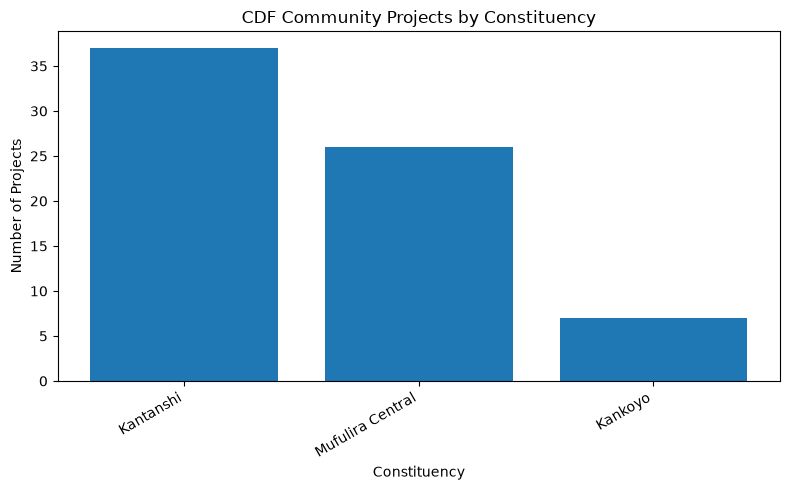

In [19]:
if constituency_col:
    constituency_counts = df_cleaned[constituency_col].value_counts()

    plt.figure(figsize=(8, 5))
    plt.bar(
        constituency_counts.index.astype(str),
        constituency_counts.values
    )
    plt.title("CDF Community Projects by Constituency")
    plt.xlabel("Constituency")
    plt.ylabel("Number of Projects")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

### 12.2 Projects by Sector

A bar chart is used to show how the extracted community projects are distributed across development sectors.

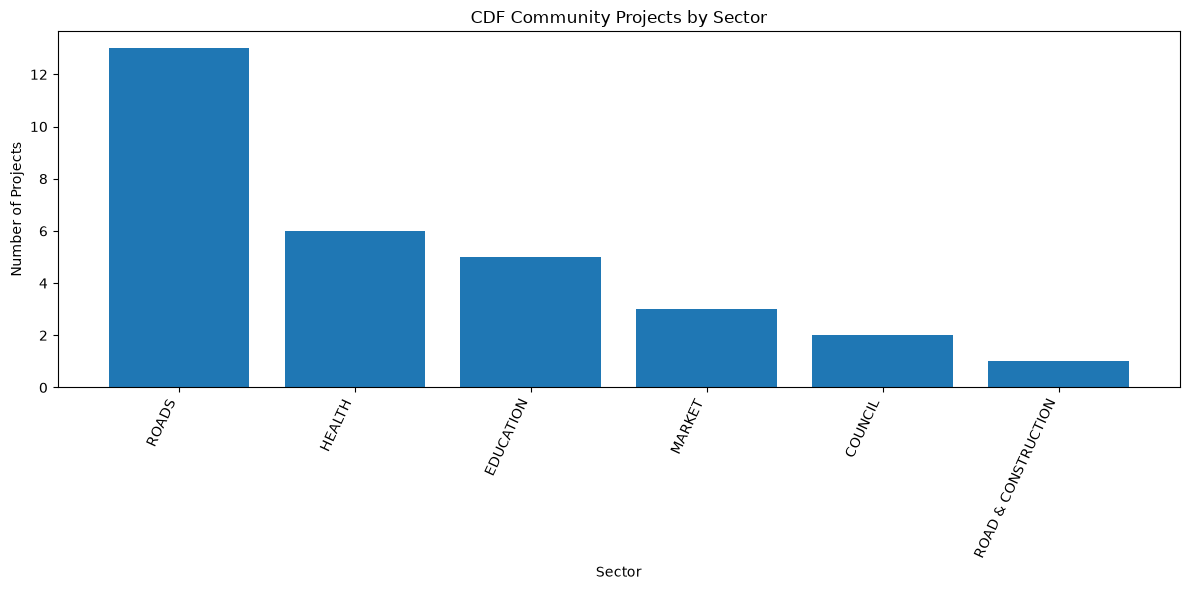

In [20]:
if sector_col:
    sector_counts = df_cleaned[sector_col].value_counts()

    plt.figure(figsize=(12, 6))
    plt.bar(
        sector_counts.index.astype(str),
        sector_counts.values
    )
    plt.title("CDF Community Projects by Sector")
    plt.xlabel("Sector")
    plt.ylabel("Number of Projects")
    plt.xticks(rotation=65, ha="right")
    plt.tight_layout()
    plt.show()

## 13. Financial Data Cleaning

The CDF dataset contains an engineer's estimate and an approved amount for projects.

These fields are converted to numeric values where possible. Commas, currency text, and surrounding whitespace are removed before conversion.

Values that cannot be reliably interpreted as numbers are retained as missing rather than being assigned arbitrary values.

In [21]:
def find_matching_column(columns, required_terms):
    for column in columns:
        name = str(column).lower()
        if all(term.lower() in name for term in required_terms):
            return column
    return None


estimate_col = find_matching_column(
    df_cleaned.columns,
    ["engineer", "estimate"]
)

approved_col = find_matching_column(
    df_cleaned.columns,
    ["approved", "amount"]
)

print("Engineer's estimate column:", estimate_col)
print("Approved amount column:", approved_col)

if estimate_col:
    df_cleaned["engineers_estimate_numeric"] = pd.to_numeric(
        df_cleaned[estimate_col]
        .astype("string")
        .str.replace(",", "", regex=False)
        .str.replace("ZMW", "", regex=False)
        .str.replace("K", "", regex=False)
        .str.strip(),
        errors="coerce"
    )

if approved_col:
    df_cleaned["approved_amount_numeric"] = pd.to_numeric(
        df_cleaned[approved_col]
        .astype("string")
        .str.replace(",", "", regex=False)
        .str.replace("ZMW", "", regex=False)
        .str.replace("K", "", regex=False)
        .str.strip(),
        errors="coerce"
    )

if "engineers_estimate_numeric" in df_cleaned:
    print(
        "\nEngineer estimates converted:",
        df_cleaned["engineers_estimate_numeric"].notna().sum()
    )

if "approved_amount_numeric" in df_cleaned:
    print(
        "Approved amounts converted:",
        df_cleaned["approved_amount_numeric"].notna().sum()
    )

Engineer's estimate column: engineers_estimate_zmw
Approved amount column: approved_amount_zmw

Engineer estimates converted: 51
Approved amounts converted: 60


## 14. Proposed-Date Cleaning

The proposed project date is converted to a standard datetime representation where the extracted value can be interpreted as a valid date.

Unparseable values are retained as missing rather than being guessed.

In [22]:
date_col = find_matching_column(
    df_cleaned.columns,
    ["proposed", "date"]
)

print("Proposed-date column:", date_col)

if date_col:
    df_cleaned["proposed_date_clean"] = pd.to_datetime(
        df_cleaned[date_col],
        errors="coerce",
        dayfirst=True
    )

    print(
        "Successfully parsed dates:",
        df_cleaned["proposed_date_clean"].notna().sum()
    )

    print(
        "Unparseable/unavailable dates:",
        df_cleaned["proposed_date_clean"].isna().sum()
    )

Proposed-date column: proposed_date
Successfully parsed dates: 0
Unparseable/unavailable dates: 70


## 15. Numerical Validity Checks

Numeric project quantities and financial values are checked for negative values.

Negative quantities or negative monetary amounts would be inconsistent with the meaning of these fields and would require investigation.

In [23]:
numeric_candidates = [
    column for column in [
        "engineers_estimate_numeric",
        "approved_amount_numeric"
    ]
    if column in df_cleaned.columns
]

for column in numeric_candidates:
    negative_count = (df_cleaned[column] < 0).sum()
    print(f"{column}: {negative_count} negative values")

quantity_col = next(
    (c for c in df_cleaned.columns if "quantity" in c),
    None
)

if quantity_col:
    quantity_numeric = pd.to_numeric(
        df_cleaned[quantity_col]
        .astype("string")
        .str.replace(",", "", regex=False)
        .str.strip(),
        errors="coerce"
    )

    print(
        "Quantity:",
        (quantity_numeric < 0).sum(),
        "negative values"
    )

engineers_estimate_numeric: 0 negative values
approved_amount_numeric: 0 negative values
Quantity: 0 negative values


## 16. Approved Amount Analysis

The approved project amounts are summarized after numerical conversion.

This allows the distribution of project funding to be explored without altering the original extracted monetary field.

In [24]:
if "approved_amount_numeric" in df_cleaned.columns:
    print(
        df_cleaned["approved_amount_numeric"]
        .describe()
    )

count              60.0
mean       1429924.5475
std      5874516.502541
min             60000.0
25%            285000.0
50%            400000.0
75%           833775.45
max          45746000.0
Name: approved_amount_numeric, dtype: Float64


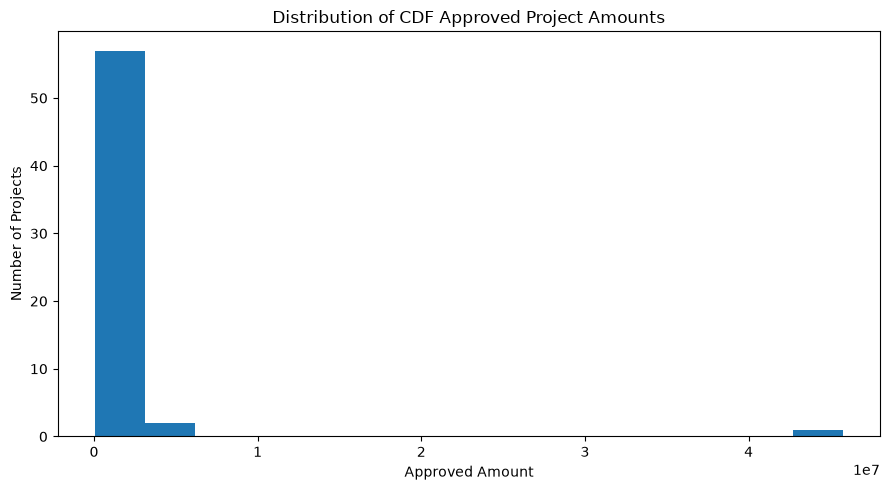

In [25]:
if "approved_amount_numeric" in df_cleaned.columns:

    plt.figure(figsize=(9, 5))
    plt.hist(
        df_cleaned["approved_amount_numeric"].dropna(),
        bins=15
    )
    plt.title("Distribution of CDF Approved Project Amounts")
    plt.xlabel("Approved Amount")
    plt.ylabel("Number of Projects")
    plt.tight_layout()
    plt.show()

## 17. Post-Cleaning Verification

The cleaned dataframe is checked to ensure that:

- the original number of project records has been preserved;
- text fields have been standardized;
- numerical financial fields have been converted where possible;
- dates have been standardized where possible; and
- no unsupported values have been invented.

In [26]:
print("Original rows:", len(df))
print("Cleaned rows:", len(df_cleaned))

print("\nCleaned dataframe shape:")
print(df_cleaned.shape)

print("\nRemaining missing values:")
display(df_cleaned.isna().sum())

print("\nCleaned dataframe preview:")
display(df_cleaned.head())

Original rows: 70
Cleaned rows: 70

Cleaned dataframe shape:
(70, 17)

Remaining missing values:


constituency                   0
project_no                     0
ward                          40
project_name                   4
sector                        40
scope_of_work                  0
quantity                      70
location                      70
proposed_date                 70
duration                      27
engineers_estimate_zmw        19
approved_amount_zmw           10
justification                 70
source_file                    0
engineers_estimate_numeric    19
approved_amount_numeric       10
proposed_date_clean           70
dtype: int64


Cleaned dataframe preview:


,constituency,project_no,ward,project_name,sector,scope_of_work,quantity,location,proposed_date,duration,engineers_estimate_zmw,approved_amount_zmw,justification,source_file,engineers_estimate_numeric,approved_amount_numeric,proposed_date_clean
0,Kantanshi,1,DAVID KAUNDA,| 2? | PURCHASE OF 985 DESKS MUFULIRA SECONDAR...,EDUCATION,| 2? | Purchase of 985 Desks Mufulira Secondar...,NaN,NaN,NaN,8 WEEKS,374000.0,374000.0,NaN,Kantanshi-Comm-Projects.pdf,374000.0,374000.0,NaT
1,Kantanshi,3,MAINASOKO,"TWALUBUKA 50 TWALUBUKA 15TH MARCH, 2025 |",<NA>,"Twalubuka 50 Twalubuka 15th March, 2025 |Maina...",NaN,NaN,NaN,8 WEEKS,110000.0,110000.0,NaN,Kantanshi-Comm-Projects.pdf,110000.0,110000.0,NaT
2,Kantanshi,3,MOKAMBO,MURUNDU SECONDARY 40 MURUNDU SECONDARY 15TH MA...,<NA>,Murundu Secondary 40 Murundu Secondary 15th Ma...,NaN,NaN,NaN,8 WEEKS,88000.0,88000.0,NaN,Kantanshi-Comm-Projects.pdf,88000.0,88000.0,NaT
3,Kantanshi,8,MOKAMBO,<NA>,<NA>,Mokambo Secondary | 40 Mokambo Secondary 15th ...,NaN,NaN,NaN,8 WEEKS,88000.0,88000.0,NaN,Kantanshi-Comm-Projects.pdf,88000.0,88000.0,NaT
4,Kantanshi,4,DAVID KAUNDA,PAMODZI SECONDARY 30 PAMODZI SECONDARY 15TH MA...,EDUCATION,Pamodzi Secondary 30 Pamodzi Secondary 15th Ma...,NaN,NaN,NaN,8 WEEKS,66000.0,66000.0,NaN,Kantanshi-Comm-Projects.pdf,66000.0,66000.0,NaT


## 18. EDA Findings

The CDF Community Projects dataset contains project records collected from official Mufulira Municipal Council Community Projects documents for Kantanshi, Kankoyo, and Mufulira Central.

The EDA examined the structure, completeness, duplication, categorical distributions, financial fields, dates, and numerical validity of the extracted records.

Because the source documents included scanned PDFs processed through OCR, particular attention was given to text consistency and the conversion of extracted financial and date values into usable analytical formats.

The analysis also distinguishes between genuine missing information and values that were unavailable or could not be reliably interpreted from the extracted source.

No records are removed solely because individual attributes are unavailable. Instead, records are retained and problematic values are converted to missing values only when their original contents cannot be reliably interpreted.

The resulting cleaned dataframe provides a structured basis for further analysis of Mufulira Municipal Council CDF community projects.

## 19. Cleaning and Preprocessing Summary

The following preprocessing operations were applied:

1. A separate working dataframe, `df_cleaned`, was created so that the original extracted dataset remained unchanged.
2. Text fields were stripped of unnecessary leading and trailing whitespace.
3. Column names in the analytical dataframe were standardized for consistent programming.
4. Monetary fields were converted to numeric representations where possible.
5. The proposed-date field was converted to datetime where the extracted value could be interpreted as a valid date.
6. Invalid or uninterpretable numeric/date values were represented as missing rather than being assigned arbitrary values.
7. No project records were removed solely because of missing or unavailable attributes.

## 20. Conclusion

The CDF Community Projects dataset provides structured information about community projects identified from Mufulira Municipal Council documents.

The EDA established the dataset's structure and assessed common data-quality issues associated with PDF and OCR-based extraction. The preprocessing stage standardized the analytical representation of the data while preserving the original records.

The cleaned dataframe can therefore be used for subsequent data mining and exploratory analysis, with the documented limitations of the extracted source data taken into account.